# Task Dataset Build

Builds a focused species-detector dataset

- clips from target species : XC or ebird
- clips per other-present species (pooled into `non_target`)
- AudioSet ambient clips (pooled into `non_target`)

All downloads are cached: re-running the notebook only fetches what's missing.

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from pathlib import Path

import pyrootutils

ROOT = pyrootutils.setup_root(
    search_from=Path.cwd(),
    indicator="pyproject.toml",
    pythonpath=True,
    dotenv=True,
)

# Parameters

In [4]:
from building.geographic_task import cascading_slug, task_slug

LAT, LON = 48.8566, 2.3522 # PARIS
RADIUS_KM = 50

TARGET_SPECIES = [
    "Emberiza calandra",
    "Hippolais polyglotta",
    "Regulus ignicapilla",
]

TARGET_CLIPS_PER_SPECIES = 5000
NON_TARGET_CLIPS_PER_SPECIES = 300

# Area discovery (matches analysis.ipynb defaults)
MIN_AREA_RECORDINGS = 10
ANALYSIS_MAX_BIRDNET = 500
ANALYSIS_MIN_CONF = 0.85

# AudioSet ambient/anthropic noise (diversified across ~60 FOCUS_CLASSES)
AS_CLIPS_PER_CLASS = 250
AS_MAX_TOTAL_CLIPS = 15000

# Dataset folders are slug-named so the (species, area) context is
# visible at the filesystem level and aligned with the results folder.
COLLECTION_NAME = task_slug(TARGET_SPECIES, LAT, LON, RADIUS_KM)
CASCADING_COLLECTION_NAME = cascading_slug(COLLECTION_NAME)
print(f"standard:  {COLLECTION_NAME}")
print(f"cascading: {CASCADING_COLLECTION_NAME}")

standard:  task_s3_49_2_r50
cascading: task_s3_49_2_r50_cascading


# Discover other species present in the area

In [5]:
from building.analysis import (
    area_audio_cache_dir,
    bbox_from_radius,
    birdnet_area_analysis,
    combined_species_table,
    fetch_area_recordings,
    recordings_to_df,
)

bbox = bbox_from_radius(LAT, LON, RADIUS_KM)
area_df = recordings_to_df(await fetch_area_recordings(bbox))
bn = await birdnet_area_analysis(
    area_df,
    max_recordings=ANALYSIS_MAX_BIRDNET,
    min_confidence=ANALYSIS_MIN_CONF,
    cache_dir=area_audio_cache_dir(LAT, LON, RADIUS_KM),
)
combined = combined_species_table(
    area_df, bn["detections"], min_recordings=MIN_AREA_RECORDINGS
)
OTHER_SPECIES = [
    sp for sp in combined["scientific_name"].tolist() if sp not in TARGET_SPECIES
]
print(f"{len(OTHER_SPECIES)} other species present in area")
OTHER_SPECIES

BirdNET analyse:   0%|          | 0/500 [00:00<?, ?it/s]

36 other species present in area


['Psittacula krameri',
 'Parus major',
 'Anthus spinoletta',
 'Dendrocoptes medius',
 'Curruca communis',
 'Fringilla coelebs',
 'Sylvia atricapilla',
 'Certhia brachydactyla',
 'Troglodytes troglodytes',
 'Locustella luscinioides',
 'Acrocephalus palustris',
 'Phylloscopus collybita',
 'Muscicapa striata',
 'Locustella naevia',
 'Tyto alba',
 'Erithacus rubecula',
 'Corvus corone corone',
 'Acanthis cabaret',
 'Turdus philomelos',
 'Turdus merula',
 'Alcedo atthis',
 'Poecile palustris',
 'Picus viridis',
 'Corvus corone',
 'Athene noctua',
 'Sitta europaea',
 'Cisticola juncidis',
 'Curruca undata',
 'Sylvia borin',
 'Pica pica',
 'Luscinia megarhynchos',
 'Anthus spinoletta spinoletta',
 'Acrocephalus scirpaceus',
 'Cyanistes caeruleus',
 'Dendrocopos major',
 'Falco tinnunculus']

# Stream-download target species

In [6]:
from building.data.download import download_and_process
from building.data.sources import XCSource, EBirdSource

with XCSource() as xc, EBirdSource() as eb:
    for sp in TARGET_SPECIES:
        await download_and_process(sp, TARGET_CLIPS_PER_SPECIES, [xc, eb])


=== [Emberiza calandra] target=10000 clips (5000/source × 2 sources)  on disk=8183 [xc=2609/5000, ebird=5574/5000] ===
[Emberiza calandra] --- Phase A: per-source quota ---
[Emberiza calandra / xc] no pending recordings (available=227, already processed=1960, on disk=8183/10000).
[Emberiza calandra / ebird] 5574/5000 already on disk from this source, skipping Phase A.
[Emberiza calandra] --- Phase B: top up (have 8183/10000) ---
[Emberiza calandra / xc] no pending recordings (available=227, already processed=1960, on disk=8183/10000).
[Emberiza calandra / ebird] no pending recordings (available=1733, already processed=1960, on disk=8183/10000).
[Emberiza calandra] done. final 8183/10000 clips on disk [xc=2609, ebird=5574].

=== [Hippolais polyglotta] target=10000 clips (5000/source × 2 sources)  on disk=7759 [xc=3524/5000, ebird=4235/5000] ===
[Hippolais polyglotta] --- Phase A: per-source quota ---
[Hippolais polyglotta / xc] no pending recordings (available=401, already processed=17

# Stream-download other species (250 each, pooled as non-target)

In [7]:
with XCSource() as xc, EBirdSource() as eb:
    for sp in OTHER_SPECIES:
        await download_and_process(sp, NON_TARGET_CLIPS_PER_SPECIES, [xc, eb])


=== [Psittacula krameri] target=600 clips (300/source × 2 sources)  on disk=600 [xc=452/300, ebird=148/300] ===
[Psittacula krameri] already at target, nothing to do.

=== [Parus major] target=600 clips (300/source × 2 sources)  on disk=600 [xc=300/300, ebird=300/300] ===
[Parus major] already at target, nothing to do.

=== [Anthus spinoletta] target=600 clips (300/source × 2 sources)  on disk=600 [xc=308/300, ebird=292/300] ===
[Anthus spinoletta] already at target, nothing to do.

=== [Dendrocoptes medius] target=600 clips (300/source × 2 sources)  on disk=600 [xc=300/300, ebird=300/300] ===
[Dendrocoptes medius] already at target, nothing to do.

=== [Curruca communis] target=600 clips (300/source × 2 sources)  on disk=600 [xc=300/300, ebird=300/300] ===
[Curruca communis] already at target, nothing to do.

=== [Fringilla coelebs] target=600 clips (300/source × 2 sources)  on disk=600 [xc=300/300, ebird=300/300] ===
[Fringilla coelebs] already at target, nothing to do.

=== [Sylvia

# Stream-download AudioSet ambient clips

In [8]:
from building.data.audioset import AudioSetConfig, stream_download_audioset_async

as_cfg = AudioSetConfig(
    clips_per_class=AS_CLIPS_PER_CLASS,
    max_total_clips=AS_MAX_TOTAL_CLIPS,
)
await stream_download_audioset_async(as_cfg)

[audioset] split=unbalanced_train per_class=250 global=15000 on_disk=11801 workers=6
[audioset] indexing unbalanced_train segments...
[audioset] candidates per class: Speech=936732, Male speech, man speaking=6941, Female speech, woman speaking=5057, Conversation=2140, Narration, monologue=15253, ...


[Speech] recs:   0%|          | 0/900155 [00:00<?, ?it/s]

[Speech] clips:  80%|########  | 200/250 [00:00<?, ?it/s]

[Male speech, man speaking] recs:   0%|          | 0/6741 [00:00<?, ?it/s]

[Male speech, man speaking] clips:  80%|########  | 200/250 [00:00<?, ?it/s]

...

[Howl] clips:  80%|########  | 200/250 [00:00<?, ?it/s]

[Rustling leaves] recs:   0%|          | 0/1305 [00:00<?, ?it/s]

[Rustling leaves] clips:  80%|########  | 200/250 [00:00<?, ?it/s]

: 

: 

# Pre-split summary

In [ ]:
from building.data.dataset import AUDIOSET_DIR, BIRDNET_NO_BIRD_DIR, SUBSAMPLES_DIR


def _count(folder):
    return len(list(folder.glob("*.wav"))) if folder.exists() else 0


print("Target classes:")
for sp in TARGET_SPECIES:
    print(f"  {sp}: {_count(SUBSAMPLES_DIR / sp.replace(' ', '_'))}")

as_total, as_classes = 0, 0
if AUDIOSET_DIR.exists():
    for d in sorted(AUDIOSET_DIR.iterdir()):
        if d.is_dir():
            n = _count(d)
            if n:
                as_total += n
                as_classes += 1
print(f"\nAudioSet: {as_total} clips across {as_classes} classes")

other_total, other_species_present = 0, 0
for sp in OTHER_SPECIES:
    n = _count(SUBSAMPLES_DIR / sp.replace(" ", "_"))
    if n:
        other_total += n
        other_species_present += 1
print(
    f"\nOther birds: {other_total} clips "
    f"across {other_species_present}/{len(OTHER_SPECIES)} species"
)

print(f"\nBirdNET no-bird clips: {_count(BIRDNET_NO_BIRD_DIR)}")

Target classes:
  Emberiza calandra: 8000
  Hippolais polyglotta: 7759
  Regulus ignicapilla: 8000

AudioSet: 11801 clips across 64 classes

Other birds: 19692 clips across 34/36 species

BirdNET no-bird clips: 2000


# Per-source RMS distribution (pre-split)

Looking at raw clip levels before assembling the dataset so we can see 
the level imbalance per source. Bins of 2 dB from -70 to 0 dBFS, chosen 
from an empirical sample.

scan (8000):   0%|          | 0/8000 [00:00<?, ?it/s]

scan (7759):   0%|          | 0/7759 [00:00<?, ?it/s]

scan (8000):   0%|          | 0/8000 [00:00<?, ?it/s]

scan (19692):   0%|          | 0/19692 [00:00<?, ?it/s]

scan (2000):   0%|          | 0/2000 [00:00<?, ?it/s]

scan (11801):   0%|          | 0/11801 [00:00<?, ?it/s]

group                                n     q05    q50    q95     min    max
Emberiza calandra                 8000   -50.6  -32.2  -20.6   -74.7   -7.0
Hippolais polyglotta              7759   -47.9  -30.9  -20.7   -70.9   -8.8
Regulus ignicapilla               8000   -62.7  -44.2  -27.7   -85.7  -12.0
Other birds (36 sp.)             19692   -51.8  -31.1  -19.7   -72.8   -3.0
BirdNET no-bird                   2000   -60.7  -38.8  -20.8  -200.0   -7.0
AudioSet (all)                   11801   -36.3  -19.2   -9.7   -60.8   -1.4


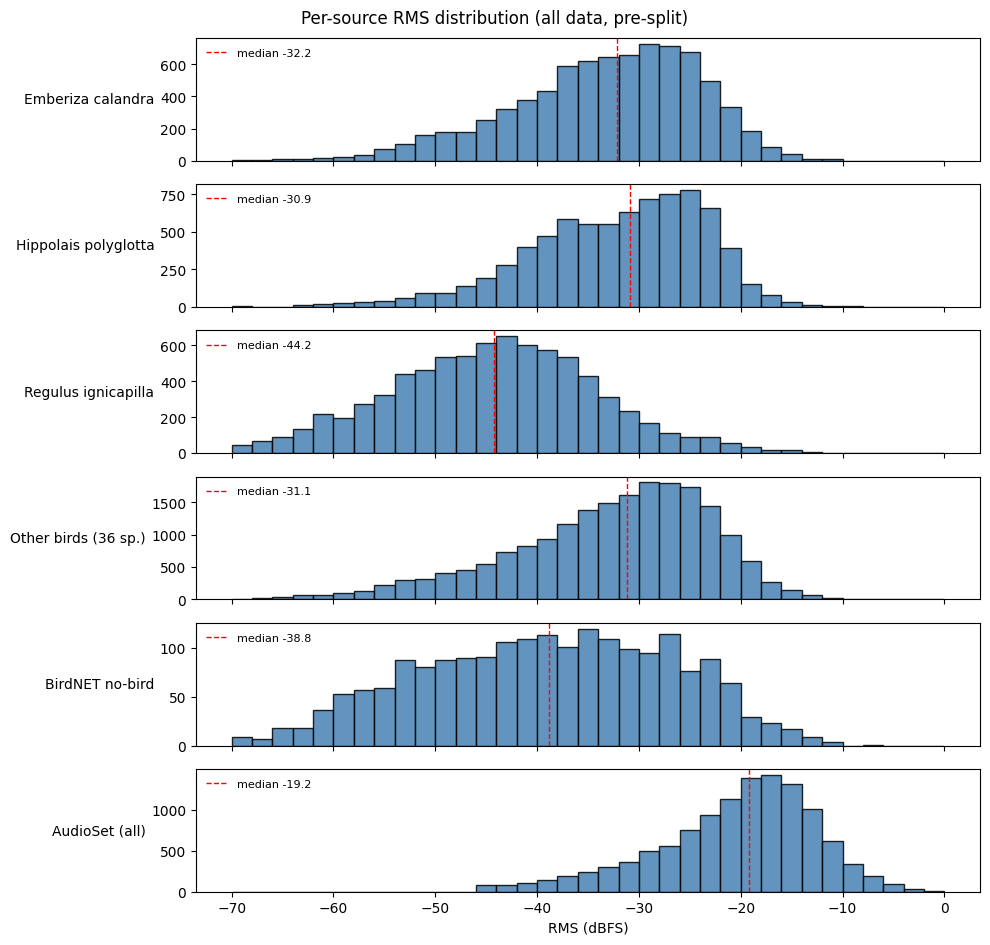

In [ ]:
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from building.data.dataset import AUDIOSET_DIR, BIRDNET_NO_BIRD_DIR, SUBSAMPLES_DIR


def _rms_dbfs(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float32)
    rms = np.sqrt(np.mean(x**2))
    return float(20.0 * np.log10(max(rms, 1e-10)))


def _scan(files: list) -> np.ndarray:
    out: list[float] = []
    for f in tqdm(files, desc=f"scan ({len(files)})", leave=False):
        try:
            x, _ = sf.read(str(f), dtype="float32", always_2d=False)
            if x.ndim > 1:
                x = x.mean(axis=-1)
            out.append(_rms_dbfs(x))
        except Exception:
            pass
    return np.array(out)


groups: list[tuple[str, np.ndarray]] = []

# One panel per target species.
for sp in TARGET_SPECIES:
    folder = SUBSAMPLES_DIR / sp.replace(" ", "_")
    if folder.exists():
        groups.append((sp, _scan(sorted(folder.glob("*.wav")))))

# Other birds aggregated.
other_files: list = []
for sp in OTHER_SPECIES:
    folder = SUBSAMPLES_DIR / sp.replace(" ", "_")
    if folder.exists():
        other_files.extend(folder.glob("*.wav"))
groups.append((f"Other birds ({len(OTHER_SPECIES)} sp.)", _scan(other_files)))

# BirdNET no-bird clips.
if BIRDNET_NO_BIRD_DIR.exists():
    groups.append(
        ("BirdNET no-bird", _scan(sorted(BIRDNET_NO_BIRD_DIR.glob("*.wav"))))
    )

# AudioSet aggregated across focus classes.
if AUDIOSET_DIR.exists():
    as_files: list = []
    for d in sorted(AUDIOSET_DIR.iterdir()):
        if d.is_dir():
            as_files.extend(d.glob("*.wav"))
    groups.append(("AudioSet (all)", _scan(as_files)))

print(
    f"{'group':<32s} {'n':>5s}  {'q05':>6s} {'q50':>6s} {'q95':>6s}  "
    f"{'min':>6s} {'max':>6s}"
)
for label, a in groups:
    if len(a) == 0:
        continue
    print(
        f"{label:<32s} {len(a):>5d}  "
        f"{np.quantile(a, 0.05):>+6.1f} {np.median(a):>+6.1f} {np.quantile(a, 0.95):>+6.1f}  "
        f"{a.min():>+6.1f} {a.max():>+6.1f}"
    )

bins = np.arange(-70, 1, 2)
n = len(groups)
fig, axes = plt.subplots(n, 1, figsize=(10, max(2.0, 1.6 * n)), sharex=True)
if n == 1:
    axes = [axes]
for ax, (label, a) in zip(axes, groups):
    if len(a):
        ax.hist(a, bins=bins, color="steelblue", edgecolor="black", alpha=0.85)
        ax.axvline(
            np.median(a), color="red", lw=1, ls="--", label=f"median {np.median(a):+.1f}"
        )
        ax.legend(loc="upper left", fontsize=8, frameon=False)
    ax.set_ylabel(label, rotation=0, ha="right", va="center")
axes[-1].set_xlabel("RMS (dBFS)")
fig.suptitle("Per-source RMS distribution (all data, pre-split)")
plt.tight_layout()
plt.show()


# Assemble train/val/test

In [ ]:
from building.data.dataset import build_task_dataset

dataset_path = build_task_dataset(
    COLLECTION_NAME,
    target_species=TARGET_SPECIES,
    non_target_species=OTHER_SPECIES,
)
print(dataset_path)

Non-target pool: 25602 clips (11801 audioset + 11801 xc_other + 2000 birdnet_no_bird)
  audioset:         take 11801 of 11801 available
  xc_other:         take 11801 of 19692 available
  birdnet_no_bird:  take 2000 of 2000 available
Processing Emberiza_calandra with 8000 clips
Training: 5600, Validation: 1200, Testing: 1200
Copied 5600 clips from Emberiza_calandra to training
Copied 1200 clips from Emberiza_calandra to validation
Copied 1200 clips from Emberiza_calandra to testing
Processing Hippolais_polyglotta with 7759 clips
Training: 5431, Validation: 1163, Testing: 1165
Copied 5431 clips from Hippolais_polyglotta to training
Copied 1163 clips from Hippolais_polyglotta to validation
Copied 1165 clips from Hippolais_polyglotta to testing
Processing Regulus_ignicapilla with 8000 clips
Training: 5600, Validation: 1200, Testing: 1200
Copied 5600 clips from Regulus_ignicapilla to training
Copied 1200 clips from Regulus_ignicapilla to validation
Copied 1200 clips from Regulus_ignicapill

# Assemble cascading train/val/test

Same raw clips as `task_dataset`, but the non-target pool is split into
`non_target_bird` (other species, XC/eBird) and `no_bird` (AudioSet +
BirdNET no-bird). `task_cascading_train` reuses this collection: stage 1
groups the bird folders against `no_bird` for a binary detector;
stage 2 trains a bird-only classifier over targets + `non_target_bird`.

In [ ]:
from building.data.dataset import build_cascading_dataset

cascading_path = build_cascading_dataset(
    CASCADING_COLLECTION_NAME,
    target_species=TARGET_SPECIES,
    non_target_species=OTHER_SPECIES,
)
print(cascading_path)